skilpool des metier 

In [1]:
import pandas as pd
import numpy as np
from datetime import timedelta
import random

# Chemin du fichier
file_path = r"C:\Users\omounabbih\Documents\project_prophet_bench\sujet_bench_triee.xlsx"


# Charger votre fichier Excel
df = pd.read_excel(file_path)

# Définir le mapping des métiers vers les domaines
metier_to_domaine = {
    # Data & Cloud
    'Data/Cloud': 'Data/Cloud',
    'Data Science': 'Data/Cloud',
    'Data Engineering': 'Data/Cloud',
    'Snowflake': 'Data/Cloud',
    'AWS/Azure': 'Data/Cloud',
    'Cloud computing': 'Data/Cloud',
    'Intelligence artificielle': 'Data/Cloud',
    # Dev Fullstack
    'Dev Fullstack': 'Dev Fullstack',
    'React': 'Dev Fullstack',
    'Node.js': 'Dev Fullstack',
    'Java Spring': 'Dev Fullstack',
    'Python': 'Dev Fullstack',
    'Développement logiciel': 'Dev Fullstack',
    # DevOps / Infra
    'DevOps': 'DevOps / Infra',
    'Kubernetes': 'DevOps / Infra',
    'Terraform': 'DevOps / Infra',
    'CI/CD': 'DevOps / Infra',
    'sysadmin': 'DevOps / Infra',
    # Agile & Delivery
    'Scrum Masters': 'Agile & Delivery',
    'Product Owner': 'Agile & Delivery',
    'Chef de project': 'Agile & Delivery',
    #Cybersecurity
    'Cybersécurité': 'Cybersécurité',
    'Blockchain' : 'Cybersécurité'
}

# Appliquer le mapping pour créer une nouvelle colonne 'domaine'
def map_metier_to_domaine(metier):
    # Si le métier n'est pas dans le mapping, on peut le laisser tel quel ou mettre 'Autre'
    return metier_to_domaine.get(metier, 'Autre')

df['domaine'] = df['metier'].apply(map_metier_to_domaine)

# Si vous souhaitez voir le résultat
print(df[['metier', 'domaine']].head(20))

# Vous pouvez aussi sauvegarder le fichier modifié
output_path = r"C:\Users\omounabbih\Documents\project_prophet_bench\sujet_bench_domaine.xlsx"
df.to_excel(output_path, index=False)

print(f"Fichier avec domaine sauvegardé : {output_path}")


                       metier           domaine
0             Cloud computing        Data/Cloud
1                      DevOps    DevOps / Infra
2                       CI/CD    DevOps / Infra
3             Cloud computing        Data/Cloud
4                  Blockchain     Cybersécurité
5               Dev Fullstack     Dev Fullstack
6                      DevOps    DevOps / Infra
7                       CI/CD    DevOps / Infra
8      Développement logiciel     Dev Fullstack
9   Intelligence artificielle        Data/Cloud
10                      CI/CD    DevOps / Infra
11              Dev Fullstack     Dev Fullstack
12  Intelligence artificielle        Data/Cloud
13  Intelligence artificielle        Data/Cloud
14              Dev Fullstack     Dev Fullstack
15              Product Owner  Agile & Delivery
16              Product Owner  Agile & Delivery
17              Dev Fullstack     Dev Fullstack
18            Cloud computing        Data/Cloud
19            Chef de project  Agile & D

•	Développement du script de transformation de données (agrégation du registre individuel en séries temporelles hebdomadaires au format Prophet : ds, y).

In [2]:
import pandas as pd
import numpy as np

# Charger votre fichier Excel
df = pd.read_excel(r"C:\Users\omounabbih\Documents\project_prophet_bench\sujet_bench_triee.xlsx")

# Convertir en datetime
df['date_entree_bench'] = pd.to_datetime(df['date_entree_bench'])
df['date_sortie_bench'] = pd.to_datetime(df['date_sortie_bench'], errors='coerce')  # pour gérer les valeurs nulles

# Définir la période de l'historique
date_min = df['date_entree_bench'].min()
date_max = df['date_sortie_bench'].max()

print(date_min)
print(date_max)

2023-01-10 00:00:00
2025-04-27 00:00:00


In [3]:
# Générer toutes les dates de lundi dans cette période
all_lundis = pd.date_range(start=date_min, end=date_max, freq='W-MON')

# Créer une liste pour stocker le résultat
weekly_counts = []

for lundi in all_lundis:
    # Filtrer les consultants actifs ce jour-là
    en_mission = df[
        (df['date_entree_bench'] <= lundi) & 
        ((df['date_sortie_bench'] >= lundi) | (df['date_sortie_bench'].isna()))
    ]
    count = len(en_mission)
    weekly_counts.append({'date': lundi, 'nb_consultants': count})

df_weekly = pd.DataFrame(weekly_counts)

# Afficher ou sauvegarder
print(df_weekly)

# Optionnel : sauvegarder dans un fichier Excel
df_weekly.to_excel(r"C:\Users\omounabbih\Documents\project_prophet_bench\rapport_par_semaine.xlsx", index=False)

          date  nb_consultants
0   2023-01-16              13
1   2023-01-23              30
2   2023-01-30              41
3   2023-02-06              49
4   2023-02-13              68
..         ...             ...
114 2025-03-24              55
115 2025-03-31              41
116 2025-04-07              28
117 2025-04-14              15
118 2025-04-21               4

[119 rows x 2 columns]


visualisation des ds et y sans skilpool

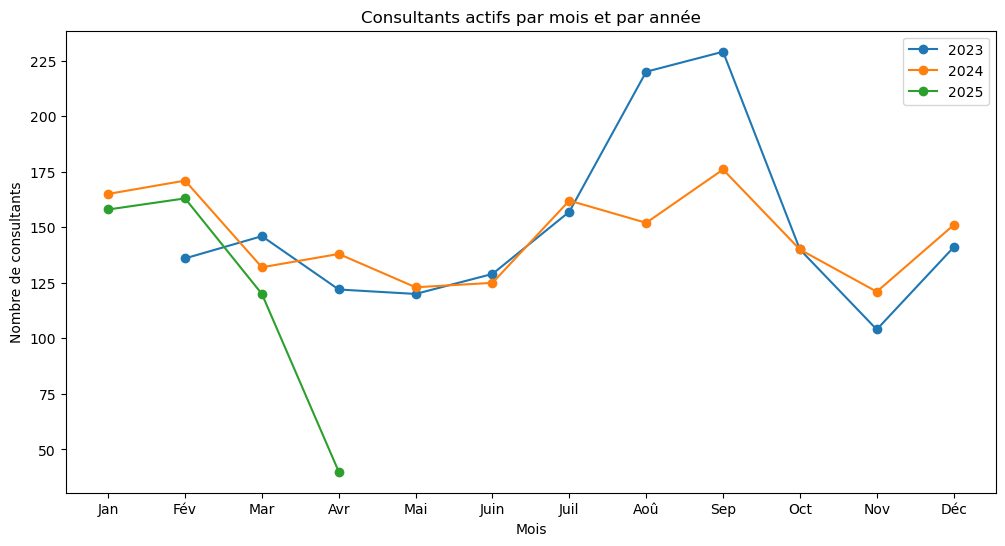

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Charger le fichier
df = pd.read_excel(r"C:\Users\omounabbih\Documents\project_prophet_bench\sujet_bench_domaine.xlsx")

# Convertir en datetime
df['date_entree_bench'] = pd.to_datetime(df['date_entree_bench'])
df['date_sortie_bench'] = pd.to_datetime(df['date_sortie_bench'], errors='coerce')

# Définir la période
date_min = df['date_entree_bench'].min()

# Générer toutes les dates de début de mois dans la période
dates_mois = pd.date_range(start=date_min, end=date_max, freq='MS')  # 'MS' = début de mois

# Créer un DataFrame pour stocker le nb de consultants par mois
data = []

for date_debut_mois in dates_mois:
    # Fin du mois
    fin_mois = date_debut_mois + pd.offsets.MonthEnd(0)
    # Filtrer si la période du consultant chevauche ce mois
    actifs = df[
        (df['date_entree_bench'] <= fin_mois) &  # début avant fin du mois
        ((df['date_sortie_bench'] >= date_debut_mois) | (df['date_sortie_bench'].isna()))  # fin après début ou toujours en mission
    ]
    data.append({'mois': date_debut_mois, 'nb_consultants': len(actifs)})


df_mensuel = pd.DataFrame(data)
df_mensuel['année'] = df_mensuel['mois'].dt.year
df_mensuel['mois_num'] = df_mensuel['mois'].dt.month

# Tracer par année
plt.figure(figsize=(12, 6))
for year in df_mensuel['année'].unique():
    df_year = df_mensuel[df_mensuel['année'] == year]
    plt.plot(df_year['mois_num'], df_year['nb_consultants'], label=str(year), marker='o')

plt.xlabel('Mois')
plt.ylabel('Nombre de consultants')
plt.title('Consultants actifs par mois et par année')
plt.legend()
plt.xticks(ticks=range(1,13), labels=['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc'])
plt.show()


Data par semaine par domain 

In [11]:
# 3. Pour chaque semaine, compter dans chaque domaine
result_list = []

for lundi in all_lundis:
    for domaine in df['domaine'].unique():
        # Filtrer les consultants actifs cette semaine dans ce domaine
        en_mission = df[
            (df['date_entree_bench'] <= lundi) & 
            ((df['date_sortie_bench'] >= lundi) | (df['date_sortie_bench'].isna())) &
            (df['domaine'] == domaine)
        ]
        count = len(en_mission)
        result_list.append({'ds': lundi, 'y': count, 'domaine': domaine})

# 4. Créer la DataFrame finale
df_final = pd.DataFrame(result_list)

# 5. Vérification
print(df_final.head(20))

# 6. Sauvegarde optionnelle
#df_final.to_excel(r"C:\Users\omounabbih\Documents\project_prophet_bench\rapport_par_semaine_domaine.xlsx", index=False)

           ds   y           domaine
0  2023-01-16   4        Data/Cloud
1  2023-01-16   5    DevOps / Infra
2  2023-01-16   1     Cybersécurité
3  2023-01-16   3     Dev Fullstack
4  2023-01-16   0  Agile & Delivery
5  2023-01-16   0             Autre
6  2023-01-23   8        Data/Cloud
7  2023-01-23   6    DevOps / Infra
8  2023-01-23   5     Cybersécurité
9  2023-01-23   7     Dev Fullstack
10 2023-01-23   4  Agile & Delivery
11 2023-01-23   0             Autre
12 2023-01-30   7        Data/Cloud
13 2023-01-30   8    DevOps / Infra
14 2023-01-30   9     Cybersécurité
15 2023-01-30  10     Dev Fullstack
16 2023-01-30   7  Agile & Delivery
17 2023-01-30   0             Autre
18 2023-02-06  10        Data/Cloud
19 2023-02-06   9    DevOps / Infra


visualisation des 5 domaine sur les 3 ans (2023,2024,2025)

C:\Users\omounabbih\AppData\Local\Temp\ipykernel_2556\1638060454.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(domaines))


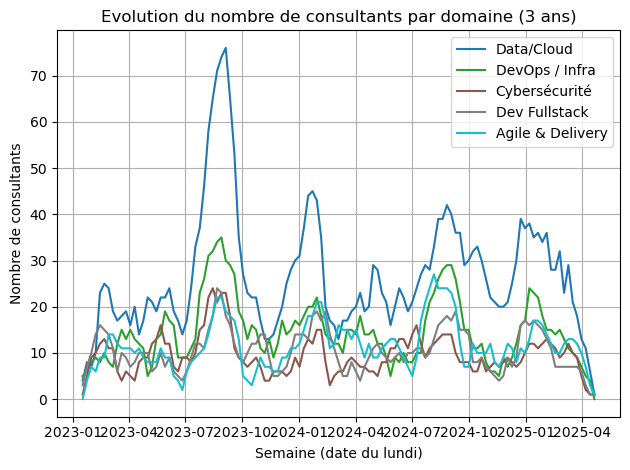

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Charger votre fichier
df = pd.read_excel(r"C:\Users\omounabbih\Documents\project_prophet_bench\rapport_par_semaine_domaine.xlsx")

# Convertir la colonne ds en datetime
df['ds'] = pd.to_datetime(df['ds'])

# Liste des domaines
domaines = df['domaine'].unique()

# Définir une palette de couleurs
colors = plt.cm.get_cmap('tab10', len(domaines))

# Pour chaque domaine, tracer l'évolution
for i, domaine in enumerate(domaines):
    df_domaine = df[df['domaine'] == domaine]
    plt.plot(df_domaine['ds'], df_domaine['y'], label=domaine, color=colors(i))
    
plt.title("Evolution du nombre de consultants par domaine (3 ans)")
plt.xlabel("Semaine (date du lundi)")
plt.ylabel("Nombre de consultants")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [13]:
df = pd.read_excel(r"C:\Users\omounabbih\Documents\project_prophet_bench\sujet_bench_domaine.xlsx")

print(df['domaine'].value_counts())


domaine
Data/Cloud          706
DevOps / Infra      399
Agile & Delivery    308
Dev Fullstack       283
Cybersécurité       272
Autre                 1
Name: count, dtype: int64


In [14]:
import numpy as np
import pandas as pd

# 1. Définir le nombre de consultants réels par domaine (Pool de consultants)
# Par exemple : 150 personnes distinctes en Data/Cloud pour 706 lignes d'intercontrat
effectifs_par_domaine = {
    'Data/Cloud': 200,
    'DevOps / Infra': 80,
    'Agile & Delivery': 65,
    'Dev Fullstack': 60,
    'Cybersécurité': 55,
    'Autre': 1,
}

# Fixer le seed pour rendre la génération reproductible
np.random.seed(42)

# 2. Fonction de réattribution des IDs
séries_ids = []

for domaine, group in df.groupby('domaine', sort=False):
    nbr_lignes = len(group)
    # Récupérer la taille du pool (50 par défaut si non trouvé)
    taille_pool = effectifs_par_domaine.get(domaine, 50)

    # Nettoyer le nom du domaine pour créer des IDs propres (ex: CONS_Data_Cloud_001 à CONS_Data_Cloud_150)
    nom_clean = (
        domaine.replace('/', '_').replace('&', 'and').replace(' ', '_')
    )
    pool_consultants = [
        f'CONS_{nom_clean}_{i+1:03d}' for i in range(taille_pool)
    ]

    # Tirage aléatoire avec remise parmi le pool pour faire répéter les consultants
    ids_attribues = np.random.choice(pool_consultants, size=nbr_lignes)

    séries_ids.append(pd.Series(ids_attribues, index=group.index))

# 3. Remplacer la colonne id_consultant
df['id_consultant'] = pd.concat(séries_ids).sort_index()

In [15]:
# 1. Nombre de consultants uniques par domaine
print('Nombre de personnes uniques par domaine :')
print(df.groupby('domaine')['id_consultant'].nunique())

# 2. Vérifier les doublons / récidivistes
doublons = df[df.duplicated(subset=['id_consultant'], keep=False)]
print(
    f'\nNombre de lignes correspondant à des récidivistes : {len(doublons)}'
)

# 3. Voir le top 5 des consultants qui sont tombés le plus souvent au bench
print('\nTop 5 des consultants avec le plus de passages au bench :')
print(df['id_consultant'].value_counts().head(5))

#output_path = r"C:\Users\omounabbih\Documents\project_prophet_bench\sujet_bench_domaine2.xlsx"
#df.to_excel(output_path, index=False)

Nombre de personnes uniques par domaine :
domaine
Agile & Delivery     64
Autre                 1
Cybersécurité        55
Data/Cloud          192
Dev Fullstack        60
DevOps / Infra       79
Name: id_consultant, dtype: int64

Nombre de lignes correspondant à des récidivistes : 1943

Top 5 des consultants avec le plus de passages au bench :
id_consultant
CONS_Data_Cloud_099        11
CONS_DevOps___Infra_051    11
CONS_Data_Cloud_190        11
CONS_DevOps___Infra_005    10
CONS_DevOps___Infra_075    10
Name: count, dtype: int64


calcule du tace de chaque semaine pour chaque domaine

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_excel(r"C:\Users\omounabbih\Documents\project_prophet_bench\rapport_par_semaine_domaine.xlsx")

# 1. Renseigne le dictionnaire avec tes vrais effectifs par domaine
effectifs = {
    'Data/Cloud': 192,  # Remplace par ton vrai chiffre
    'DevOps / Infra': 79,  # Remplace par ton vrai chiffre
    'Agile & Delivery': 64,  # Remplace par ton vrai chiffre
    'Dev Fullstack': 60,  # Remplace par ton vrai chiffre
    'Cybersécurité': 55,  # Remplace par ton vrai chiffre
    'Autre': 1,  # Remplace par ton vrai chiffre
}

# 2. Associer l'effectif total à chaque ligne
df['effectif_total'] = df['domaine'].map(effectifs)

# 3. Calculer le TACE en pourcentage (%)
df['tace'] = ((df['effectif_total'] - df['y']) / df['effectif_total']) * 100

#output_path = (r"C:\Users\omounabbih\Documents\project_prophet_bench\rapport_par_semaine_domaine2.xlsx")
#df.to_excel(output_path, index=False)

df.head(10)

,ds,y,domaine,effectif_total,tace
0,2023-01-16,4,Data/Cloud,192,97.916667
1,2023-01-16,5,DevOps / Infra,79,93.670886
2,2023-01-16,1,Cybersécurité,55,98.181818
3,2023-01-16,3,Dev Fullstack,60,95.000000
4,2023-01-16,0,Agile & Delivery,64,100.000000
5,2023-01-23,8,Data/Cloud,192,95.833333
6,2023-01-23,6,DevOps / Infra,79,92.405063
7,2023-01-23,5,Cybersécurité,55,90.909091
8,2023-01-23,7,Dev Fullstack,60,88.333333
9,2023-01-23,4,Agile & Delivery,64,93.750000


In [17]:
# Afficher la moyenne, le min et le max du TACE par domaine
stats_tace = df.groupby('domaine')['tace'].agg(['mean', 'min', 'max']).round(2)
print(stats_tace)
# Lister les semaines où le TACE est inférieur à 80%
alertes = df[df['tace'] < 80][['ds', 'domaine', 'y', 'effectif_total', 'tace']]
print(alertes.sort_values(by='tace'))

                   mean    min     max
domaine                               
Agile & Delivery  81.85  57.81  100.00
Cybersécurité     82.58  56.36   98.18
Data/Cloud        86.07  60.42   99.48
Dev Fullstack     82.51  60.00   98.33
DevOps / Infra    81.66  55.70  100.00
            ds           domaine   y  effectif_total       tace
161 2023-08-28    DevOps / Infra  35              79  55.696203
152 2023-08-14     Cybersécurité  24              55  56.363636
156 2023-08-21    DevOps / Infra  34              79  56.962025
409 2024-08-05  Agile & Delivery  27              64  57.812500
162 2023-08-28     Cybersécurité  23              55  58.181818
..         ...               ...  ..             ...        ...
569 2025-03-17  Agile & Delivery  13              64  79.687500
196 2023-10-16    DevOps / Infra  16              79  79.746835
506 2024-12-23    DevOps / Infra  16              79  79.746835
251 2024-01-01    DevOps / Infra  16              79  79.746835
106 2023-06-12    DevOp

Visualiser l'évolution du TACE au cours du temps

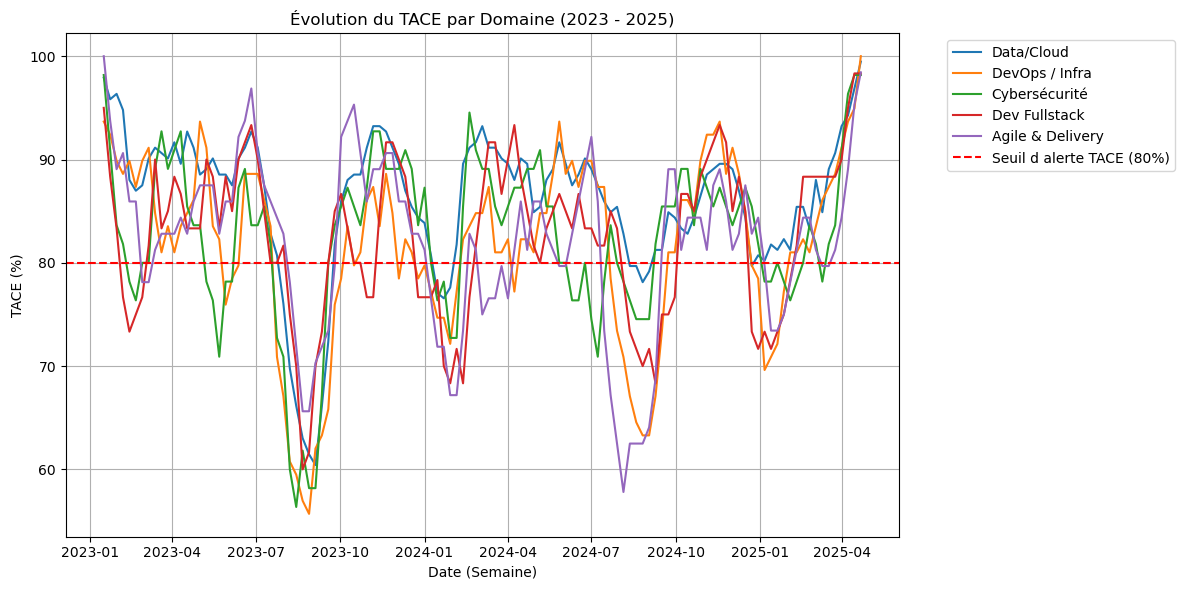

In [18]:
df = pd.read_excel(r"C:\Users\omounabbih\Documents\project_prophet_bench\rapport_par_semaine_domaine.xlsx")
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='ds', y='tace', hue='domaine')
plt.axhline(
    y=80, color='red', linestyle='--', label='Seuil d alerte TACE (80%)'
)

plt.title('Évolution du TACE par Domaine (2023 - 2025)')
plt.xlabel('Date (Semaine)')
plt.ylabel('TACE (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

une moyenne mobile (rolling mean) sur 4 semaines pour lisser la tendance

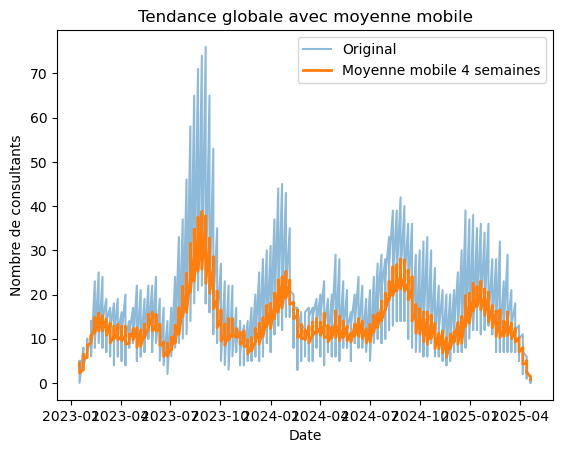

In [19]:
# Assure-toi que ton DataFrame s'appelle, par exemple, df_global
# et que la colonne 'y' contient la série à lisser.

# Tri par date si ce n'est pas déjà fait
df_global = pd.read_excel(r"C:\Users\omounabbih\Documents\project_prophet_bench\rapport_par_semaine_domaine.xlsx")

# Appliquer une moyenne mobile sur 4 semaines (28 jours)
df_global['y_smooth'] = df_global['y'].rolling(window=4, min_periods=1).mean()

# Tracer la courbe lissée
plt.plot(df_global['ds'], df_global['y'], label='Original', alpha=0.5)
plt.plot(df_global['ds'], df_global['y_smooth'], label='Moyenne mobile 4 semaines', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Nombre de consultants')
plt.title('Tendance globale avec moyenne mobile')
plt.legend()
plt.show()


📊 Synthèse de l'Analyse de Tendance (Moyenne Mobile 4 Semaines) et Tace :
L'application d'une moyenne mobile sur 4 semaines (courbe orange) filtre le bruit des oscillations hebdomadaires et fait ressortir la dynamique réelle du bench sur la période 2023 - 2025 :
    Lissage de la volatilité court-terme : La série temporelle brute (courbe bleue) affiche une très forte variance d'une semaine à l'autre. Le lissage à 4 semaines permet d'observer la tendance de fond sans être biaisé par des micro-variations.
Validation des pics saisonniers métiers :
    Pic estival (Juillet – Août) : La courbe orange met en évidence une hausse systématique du bench chaque été (sommet à ~38 consultants en moyenne en août 2023, puis ~25 en août 2024), correspondant au gel/ralentissement des projets clients. 
    Pic de fin d'année (Décembre – Janvier) : Une seconde hausse est visible au basculement de l'année, liée aux clôtures de budgets clients et aux congés imposés.  
    
Évolution de la tendance de fond : Après un pic massif à l'été 2023, le niveau de base du bench s'est stabilisé entre 10 et 15 consultants sur 2024 et début 2025.

Validation pour le modèle Prophet : La nette répétition des motifs confirme qu'il faut activer la saisonnalité annuelle (yearly_seasonality = True) et configurer les périodes de congés/fermetures (holidays) dans le modèle Prophet. 

L'analyse exploratoire valide la présence de deux pics saisonniers majeurs (août et décembre) identifiables sur la moyenne mobile et le TACE. Les perturbations de mai, plus courtes, seront quant à elles prises en charge dans le modèle via le paramètre des jours fériés (holidays).

ajout de la coloene du regrésseur

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path

# ============================================================
# 1. Paramètres
# ============================================================

input_file = Path(
    r"C:\Users\omounabbih\Documents\project_prophet_bench\rapport_par_semaine_domaine.xlsx"
)

output_file = Path(
    r"C:\Users\omounabbih\Documents\project_prophet_bench\rapport_par_semaine_domaine_v2.xlsx"
)

# Graine pour obtenir toujours les mêmes données synthétiques
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# Intensité du lien avec le y observé 4 semaines plus tard
# Plus cette valeur est élevée, plus le lien est marqué.
LAG_EFFECT = 0.45

# Taux moyen d'opportunités par consultant et par semaine
# Les valeurs peuvent être ajustées selon votre contexte.
TAUX_OPPORTUNITES = {
    "Data/Cloud": 0.10,
    "DevOps / Infra": 0.11,
    "Cybersécurité": 0.09,
    "Dev Fullstack": 0.10,
    "Agile & Delivery": 0.08,
}

# Multiplicateurs spécifiques aux pôles
MULTIPLICATEUR_DOMAINE = {
    "Data/Cloud": 1.00,
    "DevOps / Infra": 1.05,
    "Cybersécurité": 0.90,
    "Dev Fullstack": 1.00,
    "Agile & Delivery": 0.80,
}

# ============================================================
# 2. Lecture du fichier Excel
# ============================================================

df = pd.read_excel(input_file)

# Vérification des colonnes nécessaires
required_columns = {
    "ds",
    "y",
    "domaine",
    "effectif_total",
    "tace",
}

missing_columns = required_columns - set(df.columns)

if missing_columns:
    raise ValueError(
        f"Colonnes manquantes dans le fichier : {missing_columns}"
    )

# Conversion et nettoyage
df["ds"] = pd.to_datetime(df["ds"], errors="coerce")
df["y"] = pd.to_numeric(df["y"], errors="coerce")
df["effectif_total"] = pd.to_numeric(
    df["effectif_total"],
    errors="coerce",
)

if df["ds"].isna().any():
    raise ValueError("Certaines dates de la colonne 'ds' sont invalides.")

if df["y"].isna().any():
    raise ValueError("Certaines valeurs de la colonne 'y' sont invalides.")

if df["effectif_total"].isna().any():
    raise ValueError(
        "Certaines valeurs de la colonne 'effectif_total' sont invalides."
    )

# Conservation de l'ordre initial
df["_ordre_initial"] = np.arange(len(df))

# Tri indispensable pour calculer correctement le décalage de 4 semaines
df = df.sort_values(
    by=["domaine", "ds"]
).reset_index(drop=True)

# Vérification des domaines présents
domaines_inconnus = set(df["domaine"].unique()) - set(
    TAUX_OPPORTUNITES.keys()
)

if domaines_inconnus:
    raise ValueError(
        "Domaines non définis dans les paramètres : "
        f"{domaines_inconnus}"
    )

# ============================================================
# 3. Préparation du y à t+4 semaines
# ============================================================

# Pour chaque domaine :
# y_futur_t4 = valeur de y observée quatre lignes plus tard.
#
# Cette opération suppose que chaque domaine possède une ligne
# pour chaque semaine, ce qui est le cas de votre structure.
df["y_t_plus_4"] = (
    df.groupby("domaine")["y"]
    .shift(-4)
)

# Les quatre dernières semaines ne possèdent pas de y futur.
# On les remplace par la moyenne du domaine uniquement pour
# générer une valeur synthétique.
moyenne_par_domaine = df.groupby("domaine")["y"].transform("mean")

df["y_t_plus_4"] = df["y_t_plus_4"].fillna(moyenne_par_domaine)

# ============================================================
# 4. Normalisation du y futur par domaine
# ============================================================

# Standardisation par domaine afin de comparer les pôles
# malgré leurs tailles et niveaux de bench différents.
moyenne_y_futur = df.groupby("domaine")["y_t_plus_4"].transform("mean")
ecart_type_y_futur = df.groupby("domaine")["y_t_plus_4"].transform(
    "std"
)

# Évite une division par zéro si un domaine a toujours la même valeur
ecart_type_y_futur = ecart_type_y_futur.replace(0, 1)

df["y_t_plus_4_standardise"] = (
    df["y_t_plus_4"] - moyenne_y_futur
) / ecart_type_y_futur

# Limitation des valeurs extrêmes
df["y_t_plus_4_standardise"] = df[
    "y_t_plus_4_standardise"
].clip(-2, 2)

# ============================================================
# 5. Saisonnalité ESN
# ============================================================

def calculer_multiplicateur_saisonnier(date):
    """
    Retourne un multiplicateur de volume d'opportunités.

    - Août : baisse marquée de l'activité
    - Décembre : baisse liée aux fêtes de fin d'année
    - Janvier : légère reprise progressive
    - Reste de l'année : activité normale
    """
    mois = date.month

    if mois == 8:
        return 0.35

    if mois == 12:
        return 0.50

    if mois == 1:
        return 0.85

    return 1.00


df["multiplicateur_saisonnier"] = df["ds"].apply(
    calculer_multiplicateur_saisonnier
)

# ============================================================
# 6. Génération du volume synthétique
# ============================================================

# Taux d'opportunités selon le domaine
df["taux_opportunites"] = df["domaine"].map(
    TAUX_OPPORTUNITES
)

# Multiplicateur propre au domaine
df["multiplicateur_domaine"] = df["domaine"].map(
    MULTIPLICATEUR_DOMAINE
)

# Volume de base proportionnel à la taille de l'effectif
df["volume_base"] = (
    df["effectif_total"]
    * df["taux_opportunites"]
    * df["multiplicateur_domaine"]
)

# Effet de causalité synthétique :
#
# - Si y(t+4) est élevé, le volume à t est réduit.
# - Si y(t+4) est faible, le volume à t est augmenté.
#
# Ainsi, la relation entre volume(t) et y(t+4) est négative.
df["effet_lag"] = (
    1
    - LAG_EFFECT * df["y_t_plus_4_standardise"]
)

# Protection contre des volumes trop faibles ou trop élevés
df["effet_lag"] = df["effet_lag"].clip(
    lower=0.35,
    upper=1.80,
)

# Bruit multiplicatif réaliste d'environ 10 %
bruit = rng.normal(
    loc=1.0,
    scale=0.10,
    size=len(df),
)

# Évite les valeurs négatives dues au bruit
bruit = np.clip(bruit, 0.70, 1.30)

# Calcul final du volume
volume_synthetique = (
    df["volume_base"]
    * df["multiplicateur_saisonnier"]
    * df["effet_lag"]
    * bruit
)

# Arrondi à un nombre entier d'opportunités
df["volume_opportunites"] = np.round(
    volume_synthetique
).astype(int)

# Un volume ne peut pas être négatif
df["volume_opportunites"] = df[
    "volume_opportunites"
].clip(lower=0)

# ============================================================
# 7. Nettoyage des colonnes techniques
# ============================================================

colonnes_techniques = [
    "_ordre_initial",
    "y_t_plus_4",
    "y_t_plus_4_standardise",
    "multiplicateur_saisonnier",
    "taux_opportunites",
    "multiplicateur_domaine",
    "volume_base",
    "effet_lag",
]

df = df.drop(columns=colonnes_techniques)

# Retour à l'ordre initial du fichier
# La colonne temporaire a été supprimée, donc on retrie
# selon ds et domaine pour conserver une structure claire.
df = df.sort_values(
    by=["ds", "domaine"]
).reset_index(drop=True)

# ============================================================
# 8. Sauvegarde dans un nouveau fichier Excel
# ============================================================

df.to_excel(output_file, index=False)

print("Fichier généré avec succès :")
print(output_file)

# ============================================================
# 9. Contrôles rapides
# ============================================================

print("\nAperçu des nouvelles données :")
print(
    df[
        [
            "ds",
            "domaine",
            "effectif_total",
            "y",
            "volume_opportunites",
        ]
    ].head(15)
)

print("\nStatistiques du volume par domaine :")
print(
    df.groupby("domaine")["volume_opportunites"]
    .agg(["min", "mean", "max"])
    .round(2)
)

print("\nVolume moyen par mois :")
print(
    df.assign(mois=df["ds"].dt.month)
    .groupby("mois")["volume_opportunites"]
    .mean()
    .round(2)
)


Fichier généré avec succès :
C:\Users\omounabbih\Documents\project_prophet_bench\rapport_par_semaine_domaine_v2.xlsx

Aperçu des nouvelles données :
           ds           domaine  effectif_total   y  volume_opportunites
0  2023-01-16  Agile & Delivery              64   0                    5
1  2023-01-16     Cybersécurité              55   1                    3
2  2023-01-16        Data/Cloud             192   4                   18
3  2023-01-16     Dev Fullstack              60   3                    2
4  2023-01-16    DevOps / Infra              79   5                   10
5  2023-01-23  Agile & Delivery              64   4                    4
6  2023-01-23     Cybersécurité              55   5                    3
7  2023-01-23        Data/Cloud             192   8                   17
8  2023-01-23     Dev Fullstack              60   7                    3
9  2023-01-23    DevOps / Infra              79   6                   11
10 2023-01-30  Agile & Delivery              64 

heatmap to see correlation between volume opportunité et nb_consultant en bench

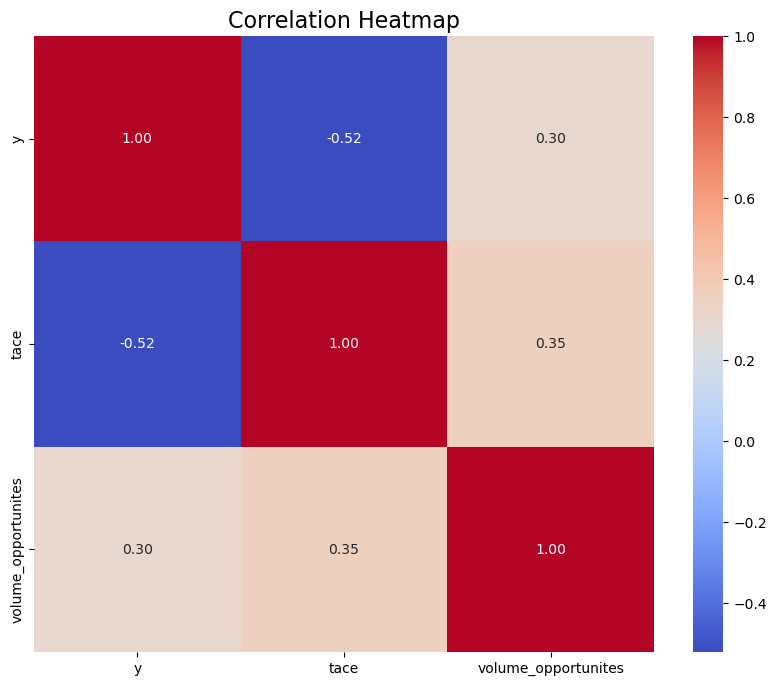

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path


input_file = Path(
    r"C:\Users\omounabbih\Documents\project_prophet_bench\rapport_par_semaine_domaine_v3.xlsx"
)

df=pd.read_excel(input_file)

df=df.drop(["ds","effectif_total"],axis=1)
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
        corr_matrix,
        annot=True,        # Show correlation values
        fmt=".2f",         # Format to 2 decimal places
        cmap="coolwarm",   # Color map
        cbar=True
    )
plt.title("Correlation Heatmap", fontsize=16)
plt.show()
